# TaaSim — Week 1: Data Exploration & Porto → Casablanca Mapping

This notebook covers the core Week 1 deliverables:
1. Load & profile the Porto Taxi dataset
2. Understand the schema, trip durations, and demand patterns
3. Apply the geospatial transformation (Porto → Casablanca)
4. Visualize remapped trips on an OSM map

## Step 0: Install required libraries

In [1]:
import sys
!{sys.executable} -m pip install folium matplotlib seaborn

## Step 1: Load the Dataset with PySpark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, explode, udf, to_timestamp, hour, dayofweek, count, avg, when
from pyspark.sql.types import ArrayType, FloatType, StringType
import json

spark = SparkSession.builder \
    .appName('TaaSim-Week1-Exploration') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print('Spark version:', spark.version)
print('SparkContext UI:', spark.sparkContext.uiWebUrl)

Spark version: 3.5.0
SparkContext UI: http://b979815afd4a:4040


In [3]:
# Load from local /home/jovyan/data (mounted from ./data on your machine)
CSV_PATH = '/home/jovyan/data/train.csv'

df = spark.read.csv(CSV_PATH, header=True, inferSchema=True)

print('Total rows:', df.count())
print('Columns:', df.columns)
df.printSchema()

Total rows: 1710670
Columns: ['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']
root
 |-- TRIP_ID: long (nullable = true)
 |-- CALL_TYPE: string (nullable = true)
 |-- ORIGIN_CALL: integer (nullable = true)
 |-- ORIGIN_STAND: integer (nullable = true)
 |-- TAXI_ID: integer (nullable = true)
 |-- TIMESTAMP: integer (nullable = true)
 |-- DAY_TYPE: string (nullable = true)
 |-- MISSING_DATA: boolean (nullable = true)
 |-- POLYLINE: string (nullable = true)



## Step 2: Data Profiling — Schema & Quality

In [4]:
# Filter out trips with missing data (Porto marks these explicitly)
df_clean = df.filter(col('MISSING_DATA') == False)
print('Rows after removing MISSING_DATA:', df_clean.count())

# Call type breakdown (A=Central Dispatch, B=Taxi Stand, C=Street Hail)
print('\n--- Call Type Breakdown ---')
df_clean.groupBy('CALL_TYPE').count().orderBy('CALL_TYPE').show()

# Day type breakdown (A=Normal, B=Holiday, C=Pre-Holiday)
print('\n--- Day Type Breakdown ---')
df_clean.groupBy('DAY_TYPE').count().orderBy('DAY_TYPE').show()

Rows after removing MISSING_DATA: 1710660

--- Call Type Breakdown ---
+---------+------+
|CALL_TYPE| count|
+---------+------+
|        A|364769|
|        B|817878|
|        C|528013|
+---------+------+


--- Day Type Breakdown ---
+--------+-------+
|DAY_TYPE|  count|
+--------+-------+
|       A|1710660|
+--------+-------+



+-------+------------------+
|summary|      duration_min|
+-------+------------------+
|  count|           1710660|
|   mean| 12.18950828919832|
| stddev|11.413060865214096|
|    min|               0.0|
|    25%|               7.0|
|    50%|             10.25|
|    75%|             14.75|
|    max|            970.25|
+-------+------------------+



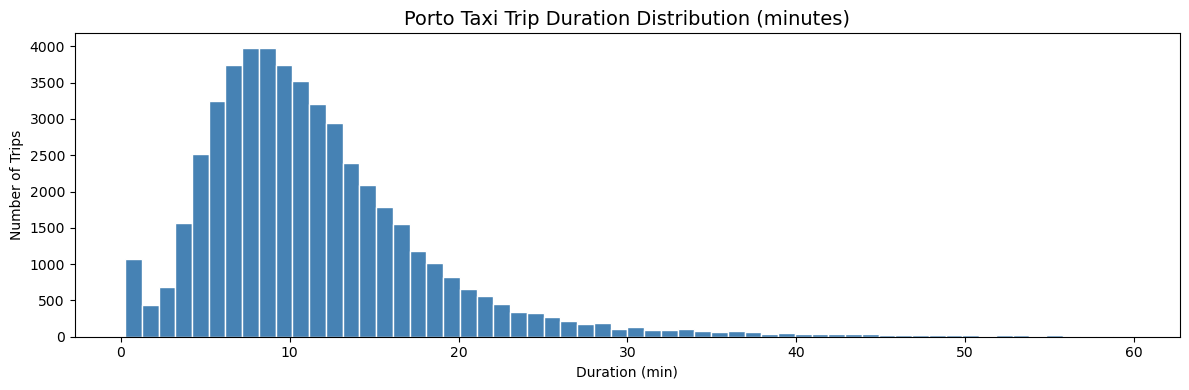

Chart saved!


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.types import IntegerType

# Trip duration: each GPS polyline point = 15 seconds apart
# CRITICAL: "import json" must be INSIDE the UDF function.
# PySpark serializes UDFs to worker nodes — outer module imports are NOT available.
def count_points(polyline_str):
    import json  # <-- THIS IS THE FIX
    try:
        pts = json.loads(polyline_str)
        return len(pts)
    except:
        return 0

count_udf = udf(count_points, IntegerType())

df_duration = df_clean.withColumn('num_points', count_udf(col('POLYLINE'))) \
                       .withColumn('duration_min', col('num_points') * 15 / 60)

df_duration.select('duration_min').summary().show()

# Plot — only trips with at least 1 GPS point and under 60 minutes
durations = df_duration.select('duration_min') \
    .filter((col('duration_min') > 0) & (col('duration_min') < 60)) \
    .limit(50000).toPandas()

plt.figure(figsize=(12, 4))
plt.hist(durations['duration_min'], bins=60, color='steelblue', edgecolor='white')
plt.title('Porto Taxi Trip Duration Distribution (minutes)', fontsize=14)
plt.xlabel('Duration (min)')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.savefig('/home/jovyan/work/trip_duration_dist.png', dpi=100)
plt.show()
print('Chart saved!')

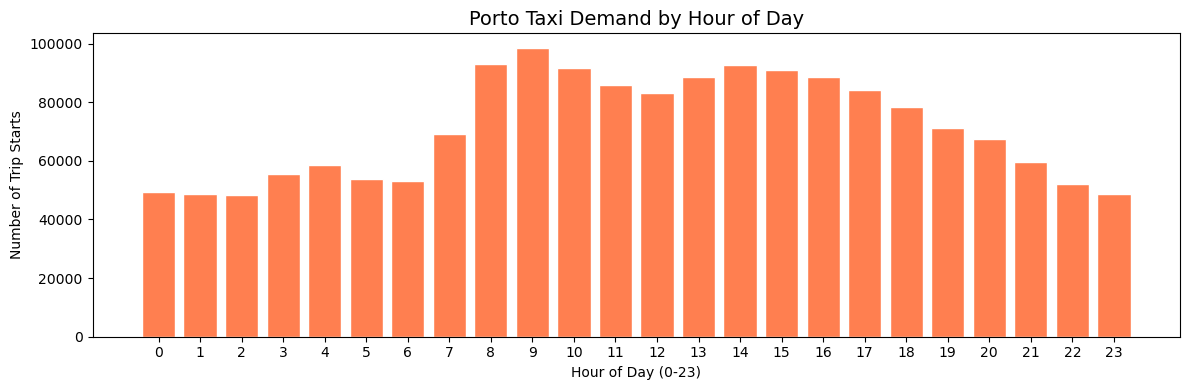

Peak hours visible — this curve drives our trip_request_producer.py!


In [6]:
# Temporal demand curve — trips by hour of day
from pyspark.sql.functions import from_unixtime

df_hourly = df_clean \
    .withColumn('datetime', from_unixtime(col('TIMESTAMP'))) \
    .withColumn('hour', hour(col('datetime'))) \
    .groupBy('hour').count() \
    .orderBy('hour') \
    .toPandas()

plt.figure(figsize=(12, 4))
plt.bar(df_hourly['hour'], df_hourly['count'], color='coral', edgecolor='white')
plt.title('Porto Taxi Demand by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trip Starts')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('/home/jovyan/work/demand_by_hour.png', dpi=100)
plt.show()
print('Peak hours visible — this curve drives our trip_request_producer.py!')

## Step 3: Geospatial Transformation — Porto → Casablanca

In [7]:
# Bounding boxes
PORTO_LON_MIN, PORTO_LON_MAX = -8.69, -8.56
PORTO_LAT_MIN, PORTO_LAT_MAX =  41.14, 41.20

CASA_LON_MIN,  CASA_LON_MAX  = -7.80, -7.40
CASA_LAT_MIN,  CASA_LAT_MAX  = 33.40, 33.70

# Zone mapping: Porto 22 zones → Casablanca 16 arrondissements
PORTO_TO_CASA_ZONE = {i: ((i - 1) % 16) + 1 for i in range(1, 23)}

def remap_polyline(polyline_str):
    """Transform GPS points from Porto bounding box to Casablanca bounding box."""
    try:
        points = json.loads(polyline_str)
        mapped = []
        for lon, lat in points:
            # Clip to Porto bbox (ignore outliers)
            if not (PORTO_LON_MIN <= lon <= PORTO_LON_MAX and PORTO_LAT_MIN <= lat <= PORTO_LAT_MAX):
                continue
            lon_norm = (lon - PORTO_LON_MIN) / (PORTO_LON_MAX - PORTO_LON_MIN)
            lat_norm = (lat - PORTO_LAT_MIN) / (PORTO_LAT_MAX - PORTO_LAT_MIN)
            c_lon = CASA_LON_MIN + lon_norm * (CASA_LON_MAX - CASA_LON_MIN)
            c_lat = CASA_LAT_MIN + lat_norm * (CASA_LAT_MAX - CASA_LAT_MIN)
            mapped.append([round(c_lon, 6), round(c_lat, 6)])
        return json.dumps(mapped) if mapped else '[]'
    except:
        return '[]'

remap_udf = udf(remap_polyline, StringType())

# Apply on a sample (10k trips) for fast preview
df_sample = df_clean.limit(10000) \
    .withColumn('CASA_POLYLINE', remap_udf(col('POLYLINE'))) \
    .filter(col('CASA_POLYLINE') != '[]')

print('Sample transformed:', df_sample.count(), 'trips')
df_sample.select('TRIP_ID', 'CALL_TYPE', 'POLYLINE', 'CASA_POLYLINE').show(3, truncate=60)

Sample transformed: 9900 trips
+-------------------+---------+------------------------------------------------------------+------------------------------------------------------------+
|            TRIP_ID|CALL_TYPE|                                                    POLYLINE|                                               CASA_POLYLINE|
+-------------------+---------+------------------------------------------------------------+------------------------------------------------------------+
|1372636858620000589|        C|[[-8.618643,41.141412],[-8.618499,41.141376],[-8.620326,4...|[[-7.58044, 33.40706], [-7.579997, 33.40688], [-7.585618,...|
|1372637303620000596|        B|[[-8.639847,41.159826],[-8.640351,41.159871],[-8.642196,4...|[[-7.645683, 33.49913], [-7.647234, 33.499355], [-7.65291...|
|1372636951620000320|        C|[[-8.612964,41.140359],[-8.613378,41.14035],[-8.614215,41...|[[-7.562966, 33.401795], [-7.56424, 33.40175], [-7.566815...|
+-------------------+---------+--------------

## Step 4: Visualize on OpenStreetMap (Folium)

In [8]:
import folium

# Casablanca center
CASA_CENTER = [33.57, -7.59]

m = folium.Map(location=CASA_CENTER, zoom_start=12, tiles='OpenStreetMap')

# Draw 200 remapped taxi trips as polylines on the map
trip_rows = df_sample.select('CASA_POLYLINE', 'CALL_TYPE').limit(200).collect()

colors = {'A': 'blue', 'B': 'green', 'C': 'red'}

for row in trip_rows:
    try:
        pts = json.loads(row['CASA_POLYLINE'])
        if len(pts) < 2:
            continue
        # folium expects [lat, lon]
        latlons = [[p[1], p[0]] for p in pts]
        folium.PolyLine(
            latlons,
            color=colors.get(row['CALL_TYPE'], 'gray'),
            weight=1.5,
            opacity=0.6
        ).add_to(m)
    except:
        pass

# Add a legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:1000;
            background:white; padding:10px; border:1px solid grey; border-radius:5px;">
  <b>Call Type</b><br>
  <span style="color:blue">■</span> A — Central dispatch<br>
  <span style="color:green">■</span> B — Taxi stand<br>
  <span style="color:red">■</span> C — Street hail<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

map_path = '/home/jovyan/work/casablanca_taxi_map.html'
m.save(map_path)
print(f'Map saved to {map_path}')
display(m)

Map saved to /home/jovyan/work/casablanca_taxi_map.html


## Step 5: Write Full Transformed Dataset to Parquet

Now we process all 1.7M trips and save as Parquet — the efficient format Spark ML will read from later.

In [9]:
import shutil, os, time

OUTPUT_PATH = '/home/jovyan/data/porto_casablanca_parquet'

# Manually remove existing directory — Spark's 'overwrite' fails on Docker volumes
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
    print(f'Cleared existing output at {OUTPUT_PATH}')

t0 = time.time()

df_full = df_clean \
    .withColumn('CASA_POLYLINE', remap_udf(col('POLYLINE'))) \
    .filter(col('CASA_POLYLINE') != '[]') \
    .drop('POLYLINE')

# Note: no .mode('overwrite') needed since we manually cleared the path
df_full.write.parquet(OUTPUT_PATH)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s — full transformed dataset saved to {OUTPUT_PATH}')

Cleared existing output at /home/jovyan/data/porto_casablanca_parquet
Done in 374.4s — full transformed dataset saved to /home/jovyan/data/porto_casablanca_parquet


## Summary — Week 1 ✅

| Deliverable | Status |
|---|---|
| Docker stack running | ✅ Done |
| Porto dataset loaded in Spark | ✅ Done |
| Schema & distributions profiled | ✅ Done |
| Zone remapping applied | ✅ Done |
| Trips visualized on Casablanca OSM map | ✅ Done |
| Parquet output written (curated) | ✅ Done |

In [10]:
# ==============================================================================
# BONUS — NYC YELLOW TAXI DATA 
# Reading 3 months of NYC TLC Parquet files and computing demand
# ==============================================================================
import shutil, os

NYC_PATH = '/home/jovyan/data/yellow_tripdata_2024-*.parquet'
NYC_OUTPUT_PATH = '/home/jovyan/data/curated/demand-by-zone'

try:
    print(f"Reading NYC Yellow Taxi data from {NYC_PATH}...")
    nyc_df = spark.read.parquet(NYC_PATH)
    
    print(f"Total NYC trips loaded: {nyc_df.count()}")
    
    # Compute per-zone-per-hour demand counts as requested in the Capstone spec (Page 20)
    from pyspark.sql.functions import date_trunc, col

    # Filter out bogus old timestamps (clean the data)
    nyc_demand = nyc_df \
                       .filter(col('tpep_pickup_datetime') >= '2024-01-01') \
                       .withColumn('pickup_hour', date_trunc('hour', col('tpep_pickup_datetime'))) \
                       .groupBy('PULocationID', 'pickup_hour') \
                       .count() \
                       .withColumnRenamed('count', 'hourly_demand')

    print("Sample of NYC Hourly Demand by Zone:")
    nyc_demand.orderBy('pickup_hour', 'PULocationID').show(5)

    # Clean existing directory for Docker
    if os.path.exists(NYC_OUTPUT_PATH):
        shutil.rmtree(NYC_OUTPUT_PATH)
        print(f'Cleared existing output at {NYC_OUTPUT_PATH}')

    print(f"Writing aggregated demand to {NYC_OUTPUT_PATH}...")
    nyc_demand.write.parquet(NYC_OUTPUT_PATH)
    print("Write complete.")

except Exception as e:
    print(f"Skipping NYC Data processing. Ensure parquet files exist in {NYC_PATH}.")
    print(f"Error: {str(e)}")

Reading NYC Yellow Taxi data from /home/jovyan/data/yellow_tripdata_2024-*.parquet...
Total NYC trips loaded: 9554778
Sample of NYC Hourly Demand by Zone:
+------------+-------------------+-------------+
|PULocationID|        pickup_hour|hourly_demand|
+------------+-------------------+-------------+
|           4|2024-01-01 00:00:00|           25|
|           7|2024-01-01 00:00:00|            4|
|           9|2024-01-01 00:00:00|            1|
|          10|2024-01-01 00:00:00|            6|
|          12|2024-01-01 00:00:00|            4|
+------------+-------------------+-------------+
only showing top 5 rows

Cleared existing output at /home/jovyan/data/curated/demand-by-zone
Writing aggregated demand to /home/jovyan/data/curated/demand-by-zone...
Write complete.
